In [63]:
import pandas as pd 
import numpy as np

In [64]:
scores = pd.read_csv('results_scored.csv')
scores

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3
...,...,...,...,...,...,...,...,...,...,...
10778,Have Mercy on me,TF-IDF,3,36.23,Psalter,37,"O Lord, rebuke me not in Thy wrath, neither ch...",True,D,0
10779,Because of the distress of ther beggars and th...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,True,A,2
10780,Because of the distress of ther beggars and th...,BERT,2,84.14,Bible,134,Alleluia Praise the name of the Lord O you ser...,True,B,1
10781,Because of the distress of ther beggars and th...,SBERT,2,97.29,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,True,C,0


In [65]:
queries = pd.read_csv('queries.csv')
#queries

In [66]:
# Create mapping: Query -> Query Category
category_map = (
    queries.set_index('Query')['Query Category']
)

# Add category column to second dataframe
scores['Query Category'] = queries['Query'].map(category_map)

In [67]:
scores['Score'].mean()

1.3660391356765278

In [68]:
avg_scores = (
    scores.groupby(["Query Category", "Method"])["Score"]
    .mean()
    .reset_index()
)

max_avg_scores = (
    avg_scores.loc[
        avg_scores.groupby("Query Category")["Score"].idxmax()
    ]
    .reset_index(drop=True)
)

print(max_avg_scores.to_latex(    index=False,
    float_format="%.2f",
    escape=False
))

\begin{tabular}{llr}
\toprule
Query Category & Method & Score \\
\midrule
Long / Complex & SBERT & 2.33 \\
Orthodox Serivce Quotes & SBERT & 2.00 \\
Phrase / Exact Match & SBERT & 1.67 \\
Short Keyword & TF-IDF + GloVe & 2.50 \\
Thematic / Semantic & TF-IDF + GloVe & 2.25 \\
\bottomrule
\end{tabular}



In [69]:
print(avg_scores.to_latex(    index=False,
    float_format="%.2f",
    escape=False
))

\begin{tabular}{llr}
\toprule
Query Category & Method & Score \\
\midrule
Long / Complex & BERT & 2.00 \\
Long / Complex & SBERT & 2.33 \\
Long / Complex & TF-IDF & 1.00 \\
Long / Complex & TF-IDF + GloVe & 1.67 \\
Orthodox Serivce Quotes & BERT & 1.50 \\
Orthodox Serivce Quotes & SBERT & 2.00 \\
Orthodox Serivce Quotes & TF-IDF & 1.67 \\
Orthodox Serivce Quotes & TF-IDF + GloVe & 1.67 \\
Phrase / Exact Match & BERT & 1.00 \\
Phrase / Exact Match & SBERT & 1.67 \\
Phrase / Exact Match & TF-IDF & 1.33 \\
Phrase / Exact Match & TF-IDF + GloVe & 0.00 \\
Short Keyword & BERT & 1.00 \\
Short Keyword & SBERT & 1.20 \\
Short Keyword & TF-IDF & 0.60 \\
Short Keyword & TF-IDF + GloVe & 2.50 \\
Thematic / Semantic & BERT & 0.25 \\
Thematic / Semantic & SBERT & 1.00 \\
Thematic / Semantic & TF-IDF & 1.00 \\
Thematic / Semantic & TF-IDF + GloVe & 2.25 \\
\bottomrule
\end{tabular}



In [70]:
pivot = pd.pivot_table(
    data=scores.dropna(subset=["Query Category"]),
    index="Query Category",
    values="Score",
    aggfunc="mean"
).reset_index()

In [71]:


# Number of rows needed in each half
mid = int(np.ceil(len(pivot) / 2))

left = pivot.iloc[:mid].reset_index(drop=True)
right = pivot.iloc[mid:].reset_index(drop=True)

# Rename columns
left.columns = ["Query Category", "Score"]
right.columns = ["Query Category", "Score"]

# Pad the right side if necessary
if len(right) < len(left):
    right = pd.concat([
        right,
        pd.DataFrame({
            "Query Category": [""],
            "Score": [np.nan]
        })
    ], ignore_index=True)

# Combine
side_by_side = pd.concat([left, right], axis=1)
side_by_side

,Query Category,Score,Query Category,Score
0,Long / Complex,1.846154,Short Keyword,1.400000
1,Orthodox Serivce Quotes,1.750000,Thematic / Semantic,1.133333
2,Phrase / Exact Match,1.125000,,NaN


In [72]:
side_by_side.to_latex()

'\\begin{tabular}{llrlr}\n\\toprule\n & Query Category & Score & Query Category & Score \\\\\n\\midrule\n0 & Long / Complex & 1.846154 & Short Keyword & 1.400000 \\\\\n1 & Orthodox Serivce Quotes & 1.750000 & Thematic / Semantic & 1.133333 \\\\\n2 & Phrase / Exact Match & 1.125000 &  & NaN \\\\\n\\bottomrule\n\\end{tabular}\n'

/tmp/ipykernel_503/91959328.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_503/91959328.py:69: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_503/91959328.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_503/91959328.py:69: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(
/tmp/ipykernel_503/91959328.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_503/91959328.py:69: Us

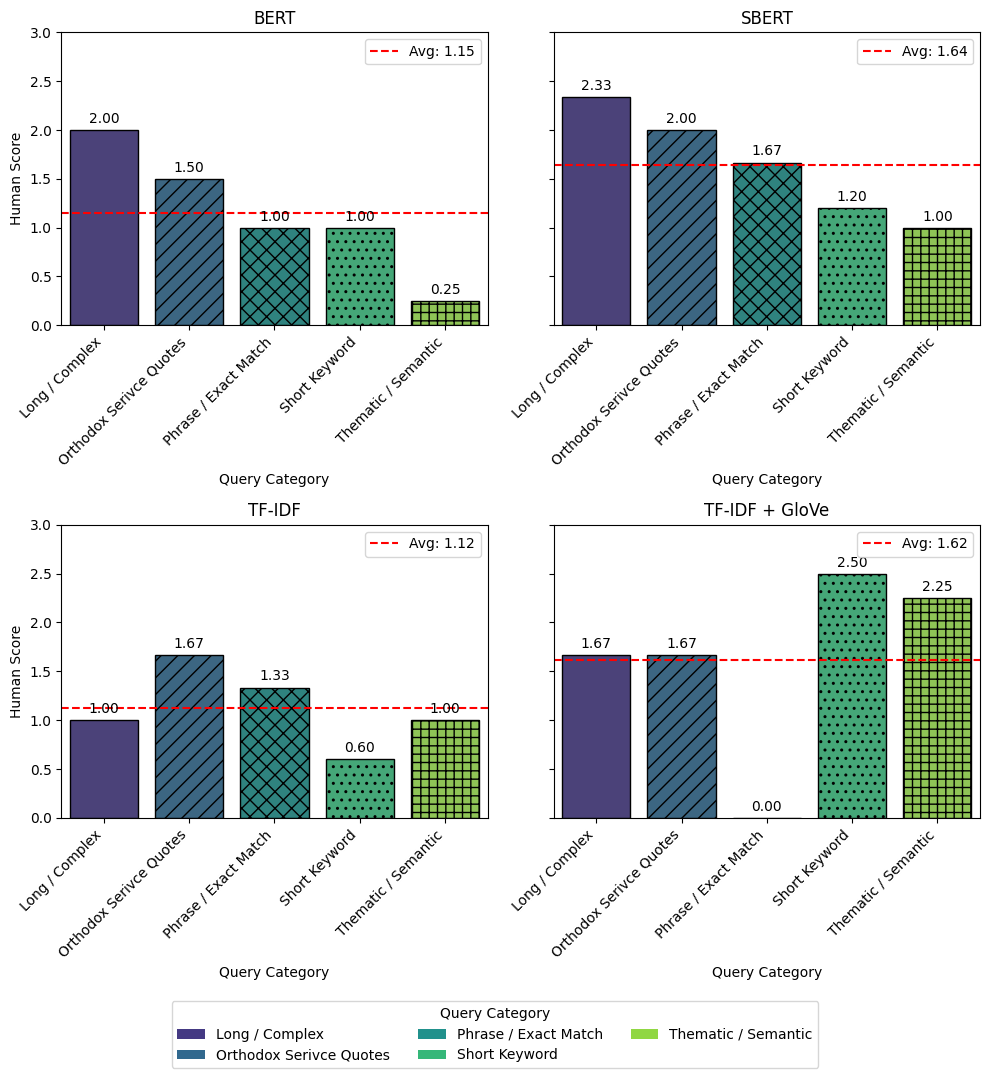

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.patches import Patch

# Pivot table
pivot = pd.pivot_table(
    scores,
    index=["Method", "Query Category"],
    values="Score",
    aggfunc="mean"
).reset_index()

methods = pivot["Method"].unique()
categories = pivot["Query Category"].unique()

# Color-blind friendly palette
palette = sns.color_palette("viridis", len(categories))
color_map = dict(zip(categories, palette))

# Texture patterns (hatching)
hatches = ["", "//", "xx", "..", "++", "\\\\", "--"]
hatch_map = dict(zip(categories, hatches))

# Determine subplot layout
n_methods = len(methods)
n_rows = 2
n_cols = math.ceil(n_methods / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), sharey=True)
axes = axes.flatten()

y_min = 0
y_max = 3

for ax, method in zip(axes, methods):

    subset = pivot[pivot["Method"] == method]

    sns.barplot(
        data=subset,
        x="Query Category",
        y="Score",
        palette=color_map,
        edgecolor="black",
        ax=ax
    )

    # Apply texture to bars
    for bar, category in zip(ax.patches, subset["Query Category"]):
        bar.set_hatch(hatch_map[category])

    # Add labels to bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)

    # Compute method average
    method_avg = subset["Score"].mean()

    ax.axhline(method_avg, color="red", linestyle="--", label=f"Avg: {method_avg:.2f}")
    ax.legend()

    ax.set_title(method)
    ax.set_xlabel("Query Category")
    ax.set_ylabel("Human Score")
    ax.set_ylim(y_min, y_max)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )

# Turn off empty axes
for ax in axes[n_methods:]:
    ax.axis("off")
legend_handles = [Patch(facecolor=color_map[c], label=c) for c in categories]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,  # forces wrapping into two rows
    title="Query Category",
    bbox_to_anchor=(0.5, -0.08)
)
legend_fig = plt.figure(figsize=(8, 2))

legend_fig.legend(
    handles=legend_handles,
    loc="center",
    ncol=3,
    title="Query Category",
    frameon=False
)

legend_fig.savefig("query_category_legend.png", bbox_inches="tight", dpi=300)
plt.close(legend_fig)
plt.tight_layout()
plt.savefig("method_cats_sepLegend.png")
plt.show()

In [74]:

# Define a color-blind-friendly palette
color_blind_palette = {
    "BERT": "#0072B2",      # blue
    "TF-IDF": "#D55E00",     # vermillion
    "SBERT": "#009E73",     # green
    "TF-IDF + GloVe": "#CC79A7"  # pink/magenta
}

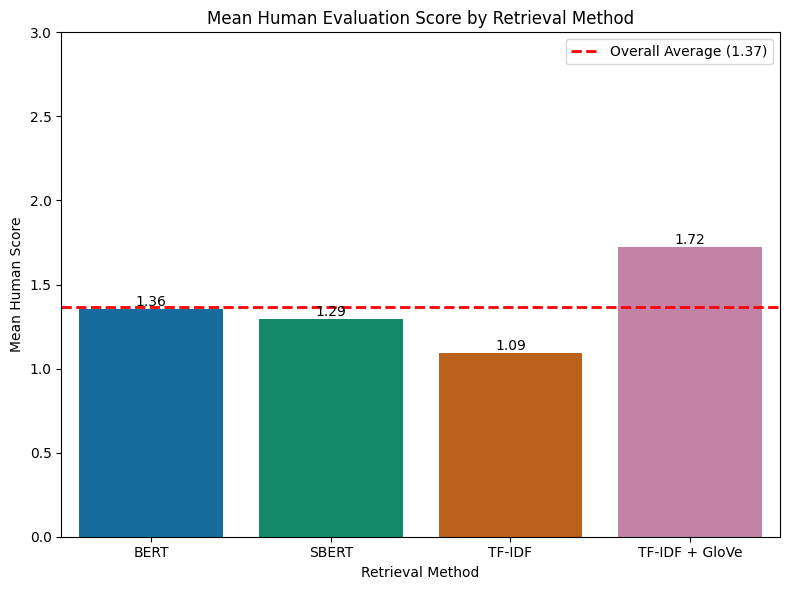

In [75]:

# Mean score per method
pivot = pd.pivot_table(
    scores,
    index="Method",
    values="Score",
    aggfunc="mean"
).reset_index()

# Overall average score
overall_avg = scores["Score"].mean()

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=pivot,
    x="Method",
    y="Score",
    hue="Method",
    dodge=False, 
    palette=color_blind_palette,
)

# Add horizontal average line
plt.axhline(overall_avg, linestyle="--", color='red', linewidth=2, label=f"Overall Average ({overall_avg:.2f})")

# Label bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.xlabel("Retrieval Method")
plt.ylabel("Mean Human Score")
plt.title("Mean Human Evaluation Score by Retrieval Method")
plt.ylim(0,3)

plt.legend()
plt.tight_layout()
plt.savefig('algorithm_avgs.png')
plt.show()

In [76]:
print(pivot.to_latex(index=False,
    float_format="%.2f",
    escape=False
))

\begin{tabular}{lr}
\toprule
Method & Score \\
\midrule
BERT & 1.36 \\
SBERT & 1.29 \\
TF-IDF & 1.09 \\
TF-IDF + GloVe & 1.72 \\
\bottomrule
\end{tabular}



## Ranks 

In [77]:
scores

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Query Category
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1,Phrase / Exact Match
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0,Orthodox Serivce Quotes
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,Orthodox Serivce Quotes
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1,Long / Complex
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3,Short Keyword
...,...,...,...,...,...,...,...,...,...,...,...
10778,Have Mercy on me,TF-IDF,3,36.23,Psalter,37,"O Lord, rebuke me not in Thy wrath, neither ch...",True,D,0,NaN
10779,Because of the distress of ther beggars and th...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,True,A,2,NaN
10780,Because of the distress of ther beggars and th...,BERT,2,84.14,Bible,134,Alleluia Praise the name of the Lord O you ser...,True,B,1,NaN
10781,Because of the distress of ther beggars and th...,SBERT,2,97.29,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,True,C,0,NaN


In [78]:
scores['Rank'].value_counts()

Rank
1    2336
2    2278
3    2228
4    2180
5    1761
Name: count, dtype: int64

In [100]:
pd.pivot_table(
    data=scores,
    index="Rank",
    values="Score",
    aggfunc="mean"
).reset_index()

,Rank,Score
0,1,1.443493
1,2,1.418349
2,3,1.398564
3,4,1.375229
4,5,1.143101


In [82]:
rank_summary = (
    pd.pivot_table(
        scores,
        index=['Method', 'Rank'],
        values='Score',
        aggfunc='mean'
    )
    .reset_index()
    .sort_values(['Method', 'Score'], ascending=[True, False])
)

display(rank_summary)

,Method,Rank,Score
0,BERT,1,1.495050
2,BERT,3,1.435352
1,BERT,2,1.397727
3,BERT,4,1.346535
4,BERT,5,1.088288
5,SBERT,1,1.419142
6,SBERT,2,1.331169
7,SBERT,3,1.256956
8,SBERT,4,1.212871
9,SBERT,5,1.199357


In [98]:
methods = rank_summary['Method'].unique()

rows = []

for method in methods:
    subset = rank_summary[rank_summary['Method'] == method]

    rank_order = ", ".join(subset['Rank'].astype(str))

    print(f"{method}: {rank_order}")
    rows.append({
        "Method": method,
        "New Ordering": rank_order
    })
new_ordering = pd.DataFrame(rows)
print("\n" +new_ordering.to_latex())

BERT: 1, 3, 2, 4, 5
SBERT: 1, 2, 3, 4, 5
TF-IDF: 4, 2, 1, 3, 5
TF-IDF + GloVe: 2, 3, 1, 4, 5

\begin{tabular}{lll}
\toprule
 & Method & New Ordering \\
\midrule
0 & BERT & 1, 3, 2, 4, 5 \\
1 & SBERT & 1, 2, 3, 4, 5 \\
2 & TF-IDF & 4, 2, 1, 3, 5 \\
3 & TF-IDF + GloVe & 2, 3, 1, 4, 5 \\
\bottomrule
\end{tabular}



In [105]:
numbered_sorted = scores.sort_values(by=['Method', 'Score'], ascending=[False, False])
numbered_sorted

# Sort by Method and Score descending
numbered_sorted = scores.sort_values(by=['Method', 'Score'], ascending=[True, False]).copy()

# Add a new column 'rank_within_method'
numbered_sorted['rank_within_method'] = numbered_sorted.groupby('Method')['Score'] \
                                                     .rank(method='first', ascending=False) \
                                                     .astype(int)

print(numbered_sorted[['Method', 'Score', 'rank_within_method']])

               Method  Score  rank_within_method
15               BERT      3                   1
40               BERT      3                   2
48               BERT      3                   3
80               BERT      3                   4
88               BERT      3                   5
...               ...    ...                 ...
10519  TF-IDF + GloVe      0                2542
10537  TF-IDF + GloVe      0                2543
10549  TF-IDF + GloVe      0                2544
10599  TF-IDF + GloVe      0                2545
10632  TF-IDF + GloVe      0                2546

[10783 rows x 3 columns]


In [130]:
pd.pivot_table(scores, index=["Method", "Query Category"], values="Score", aggfunc='mean')

Score
Method         Query Category                   
BERT           Long / Complex           2.000000
               Orthodox Serivce Quotes  1.500000
               Phrase / Exact Match     1.000000
               Short Keyword            1.000000
               Thematic / Semantic      0.250000
SBERT          Long / Complex           2.333333
               Orthodox Serivce Quotes  2.000000
               Phrase / Exact Match     1.666667
               Short Keyword            1.200000
               Thematic / Semantic      1.000000
TF-IDF         Long / Complex           1.000000
               Orthodox Serivce Quotes  1.666667
               Phrase / Exact Match     1.333333
               Short Keyword            0.600000
               Thematic / Semantic      1.000000
TF-IDF + GloVe Long / Complex           1.666667
               Orthodox Serivce Quotes  1.666667
               Phrase / Exact Match     0.000000
               Short Keyword            2.500000
               Thematic / Semantic      2.250000

In [139]:
max_scores = (
    scores
    .groupby(['Method', 'Query Category'])['Score']
    .mean()
    .reset_index()
)

max_by_category = (
    max_scores.loc[
        max_scores.groupby('Query Category')['Score'].idxmax()
    ]
    .sort_values('Score', ascending=False)
    .reset_index(drop=True)
)

max_by_category = max_by_category[
    ['Query Category', 'Method', 'Score']
]

display(max_by_category.reset_index())

print(max_by_category.to_latex())

,index,Query Category,Method,Score
0,0,Short Keyword,TF-IDF + GloVe,2.500000
1,1,Long / Complex,SBERT,2.333333
2,2,Thematic / Semantic,TF-IDF + GloVe,2.250000
3,3,Orthodox Serivce Quotes,SBERT,2.000000
4,4,Phrase / Exact Match,SBERT,1.666667


\begin{tabular}{lllr}
\toprule
 & Query Category & Method & Score \\
\midrule
0 & Short Keyword & TF-IDF + GloVe & 2.500000 \\
1 & Long / Complex & SBERT & 2.333333 \\
2 & Thematic / Semantic & TF-IDF + GloVe & 2.250000 \\
3 & Orthodox Serivce Quotes & SBERT & 2.000000 \\
4 & Phrase / Exact Match & SBERT & 1.666667 \\
\bottomrule
\end{tabular}



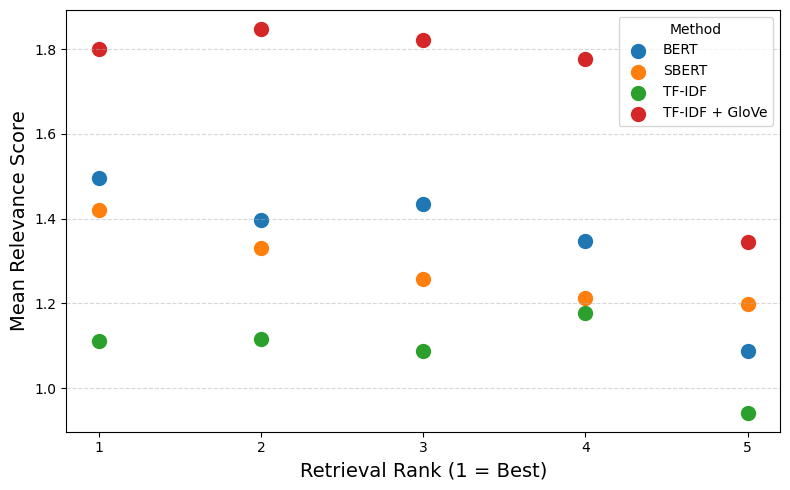

In [115]:
import matplotlib.pyplot as plt

rank_avgs = (
    scores
    .groupby(['Method', 'Rank'])['Score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

for method in rank_avgs['Method'].unique():

    method_data = rank_avgs[
        rank_avgs['Method'] == method
    ].sort_values('Rank')

    plt.scatter(
        method_data['Rank'],
        method_data['Score'],
        s=100,
        label=method
    )

plt.xlabel("Retrieval Rank (1 = Best)", fontsize=14)
plt.ylabel("Mean Relevance Score", fontsize=14)

plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Method")

plt.tight_layout()

plt.savefig(
    "rank_relevance_by_method.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

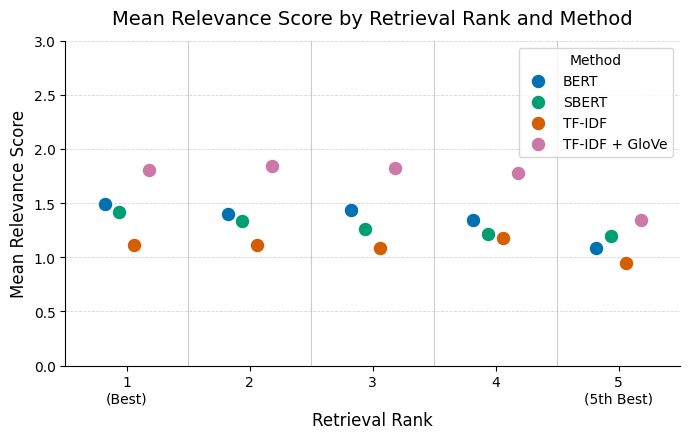

In [129]:
import numpy as np
import matplotlib.pyplot as plt

rank_avgs = (
    scores
    .groupby(['Method', 'Rank'])['Score']
    .mean()
    .reset_index()
)

methods = rank_avgs['Method'].unique()

# Small horizontal offsets so points don't overlap
offsets = np.linspace(-0.18, 0.18, len(methods))

fig, ax = plt.subplots(figsize=(7, 4.5))

'''# Very subtle alternating rank panels
for rank in range(1, 6):
    if rank % 2 == 0:
        ax.axvspan(
            rank - 0.5,
            rank + 0.5,
            color='0.95',
            zorder=0
        )
'''
# Vertical boundaries between ranks
for x in np.arange(1.5, 5, 1):
    ax.axvline(
        x,
        color='0.8',
        linewidth=0.8,
        zorder=1
    )

# Color-blind-friendly palette
color_blind_palette = {
    "BERT": "#0072B2",          # blue
    "TF-IDF": "#D55E00",        # vermillion
    "SBERT": "#009E73",         # green
    "TF-IDF + GloVe": "#CC79A7" # purple/pink
}

# Plot each method
for offset, method in zip(offsets, methods):

    method_data = (
        rank_avgs[rank_avgs['Method'] == method]
        .sort_values('Rank')
    )

    ax.scatter(
        method_data['Rank'] + offset,
        method_data['Score'],
        s=75,
        label=method,
        color=color_blind_palette[method],
        zorder=3
    )
# Axes
ax.set_xlim(0.5, 5.5)
ax.set_xticks(range(1, 6))
ax.set_xlabel("Retrieval Rank", fontsize=12)
ax.set_ylabel("Mean Relevance Score", fontsize=12)
plt.ylim(0,3)

# Make rank labels clearer
ax.set_xticklabels([
    "1\n(Best)",
    "2",
    "3",
    "4",
    "5\n(5th Best)"
])

# Horizontal grid only
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.6,
    alpha=0.5
)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(
    title="Method",
    frameon=True,
    loc='upper right'
)

ax.set_title(
    "Mean Relevance Score by Retrieval Rank and Method",
    fontsize=14,
    pad=12
)


plt.tight_layout()

plt.savefig(
    "rank_relevance_by_method.pdf",
    bbox_inches='tight'
)

plt.savefig(
    "rank_relevance_by_method.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()